# Test Độ Nhạy của Optimizer với Reproducibility trên GPU A100**GPU Target**: NVIDIA Tesla A100  **Compute Capability**: 8.0  **TF32 Support**: ✅ Hỗ trợ**Mục tiêu**: Chứng minh rằng các optimizer khác nhau (Adam, RMSProp) có độ nhạy khác nhau với các sai số nhỏ trên GPU A100, dẫn đến khuếch đại sự khác biệt giữa các GPU.**Vấn đề**: Optimizer như Adam và RMSProp sử dụng momentum và adaptive learning rate, có thể khuếch đại sai số nhỏ từ floating-point precision thành khác biệt lớn hơn.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")

    # Kiểm tra TF32 support (A100 hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")

    # Xác nhận GPU
    if "A100" not in gpu_name.upper() and "NVIDIA TESLA A100" not in gpu_name.upper():
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải A100!")
        print("   Notebook này được thiết kế cho NVIDIA Tesla A100.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU A100")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
cuDNN version: 91002
GPU: NVIDIA A100-SXM4-40GB
GPU Compute Capability: (8, 0)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU A100


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:42: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return self.getter()


## 1. Định nghĩa các hàm helper


In [2]:
def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phải là top-level function để pickle được)"""
    np.random.seed(seed_val + worker_id)

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 (Linux/Unix environment, default num_workers=4)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader - sử dụng functools.partial với function độc lập
    # (tránh lỗi pickle với nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 2. Hàm training với các optimizer khác nhau


In [3]:
def train_with_optimizer(optimizer_name, seed=42, num_epochs=10, lr=0.001,
                         tf32_enabled=False, save_results=True):
    """Train với optimizer cụ thể"""
    set_seed(seed)
    torch.backends.cudnn.allow_tf32 = tf32_enabled
    # cuBLAS TF32 (có thể không có trong một số phiên bản PyTorch)
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = tf32_enabled

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainloader, testloader = get_cifar10_loaders(batch_size=128, num_workers=4, seed=seed)

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    # Tạo optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'optimizer': optimizer_name,
        'seed': seed,
        'lr': lr,
        'tf32_enabled': tf32_enabled,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
    }

    print(f"\n{'='*70}")
    print(f"Training với {optimizer_name.upper()}")
    print(f"  GPU: {history['gpu_name']}")
    print(f"  TF32: {tf32_enabled}")
    print(f"  Seed: {seed}")
    print(f"  LR: {lr}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = history['gpu_name'].replace(' ', '_').replace('NVIDIA ', '').replace('Tesla ', '')
        filename = f"results/optimizer_a100_{optimizer_name.lower()}_seed_{seed}_{timestamp}.json"
        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\nKết quả đã lưu: {filename}")

    return history


## 3. Test với các optimizer khác nhau (cùng seed, cùng GPU)


In [4]:
# Test với Adam
history_adam = train_with_optimizer('Adam', seed=42, num_epochs=10, tf32_enabled=False)


100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]



Training với ADAM
  GPU: NVIDIA A100-SXM4-40GB
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.4598, Train Acc: 46.33% | Test Loss: 1.1160, Test Acc: 59.58%
Epoch 2/10: Train Loss: 1.1414, Train Acc: 58.96% | Test Loss: 0.9606, Test Acc: 65.54%
Epoch 3/10: Train Loss: 1.0200, Train Acc: 63.78% | Test Loss: 0.8510, Test Acc: 69.75%
Epoch 4/10: Train Loss: 0.9490, Train Acc: 66.17% | Test Loss: 0.8234, Test Acc: 70.75%
Epoch 5/10: Train Loss: 0.8992, Train Acc: 68.09% | Test Loss: 0.7510, Test Acc: 73.54%
Epoch 6/10: Train Loss: 0.8551, Train Acc: 69.84% | Test Loss: 0.7256, Test Acc: 74.42%
Epoch 7/10: Train Loss: 0.8291, Train Acc: 70.73% | Test Loss: 0.7350, Test Acc: 74.43%
Epoch 8/10: Train Loss: 0.7974, Train Acc: 71.93% | Test Loss: 0.7062, Test Acc: 74.94%
Epoch 9/10: Train Loss: 0.7666, Train Acc: 72.91% | Test Loss: 0.6801, Test Acc: 76.46%
Epoch 10/10: Train Loss: 0.7519, Train Acc: 73.58% | Test Loss: 0.6802, Test Acc: 76.00%

Kết quả đã lưu: results/optimize

In [5]:
# Test với RMSProp
history_rmsprop = train_with_optimizer('RMSprop', seed=42, num_epochs=10, tf32_enabled=False)



Training với RMSPROP
  GPU: NVIDIA A100-SXM4-40GB
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.6685, Train Acc: 41.59% | Test Loss: 1.3394, Test Acc: 51.61%
Epoch 2/10: Train Loss: 1.2464, Train Acc: 54.68% | Test Loss: 1.1058, Test Acc: 59.63%
Epoch 3/10: Train Loss: 1.1092, Train Acc: 60.19% | Test Loss: 1.1042, Test Acc: 60.93%
Epoch 4/10: Train Loss: 1.0297, Train Acc: 63.16% | Test Loss: 1.0693, Test Acc: 61.93%
Epoch 5/10: Train Loss: 0.9720, Train Acc: 65.40% | Test Loss: 0.8159, Test Acc: 71.40%
Epoch 6/10: Train Loss: 0.9308, Train Acc: 66.83% | Test Loss: 1.0209, Test Acc: 63.67%
Epoch 7/10: Train Loss: 0.8988, Train Acc: 68.06% | Test Loss: 0.9203, Test Acc: 67.97%
Epoch 8/10: Train Loss: 0.8670, Train Acc: 69.14% | Test Loss: 1.1243, Test Acc: 61.76%
Epoch 9/10: Train Loss: 0.8368, Train Acc: 70.35% | Test Loss: 0.7772, Test Acc: 72.60%
Epoch 10/10: Train Loss: 0.8149, Train Acc: 71.04% | Test Loss: 0.8299, Test Acc: 70.33%

Kết quả đã lưu: results/optim

In [6]:
# Test với SGD (để so sánh)
history_sgd = train_with_optimizer('SGD', seed=42, num_epochs=10, tf32_enabled=False)



Training với SGD
  GPU: NVIDIA A100-SXM4-40GB
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.8361, Train Acc: 32.71% | Test Loss: 1.4692, Test Acc: 45.88%
Epoch 2/10: Train Loss: 1.4805, Train Acc: 45.67% | Test Loss: 1.2689, Test Acc: 53.98%
Epoch 3/10: Train Loss: 1.3478, Train Acc: 51.21% | Test Loss: 1.1698, Test Acc: 57.69%
Epoch 4/10: Train Loss: 1.2640, Train Acc: 54.35% | Test Loss: 1.0632, Test Acc: 62.68%
Epoch 5/10: Train Loss: 1.2045, Train Acc: 56.93% | Test Loss: 1.0228, Test Acc: 63.77%
Epoch 6/10: Train Loss: 1.1536, Train Acc: 58.63% | Test Loss: 0.9673, Test Acc: 65.94%
Epoch 7/10: Train Loss: 1.1198, Train Acc: 60.22% | Test Loss: 0.9566, Test Acc: 66.35%
Epoch 8/10: Train Loss: 1.0848, Train Acc: 61.32% | Test Loss: 0.9363, Test Acc: 66.68%
Epoch 9/10: Train Loss: 1.0484, Train Acc: 62.81% | Test Loss: 0.8910, Test Acc: 68.78%
Epoch 10/10: Train Loss: 1.0310, Train Acc: 63.56% | Test Loss: 0.8781, Test Acc: 68.88%

Kết quả đã lưu: results/optimizer

## 4. So sánh kết quả giữa các optimizer


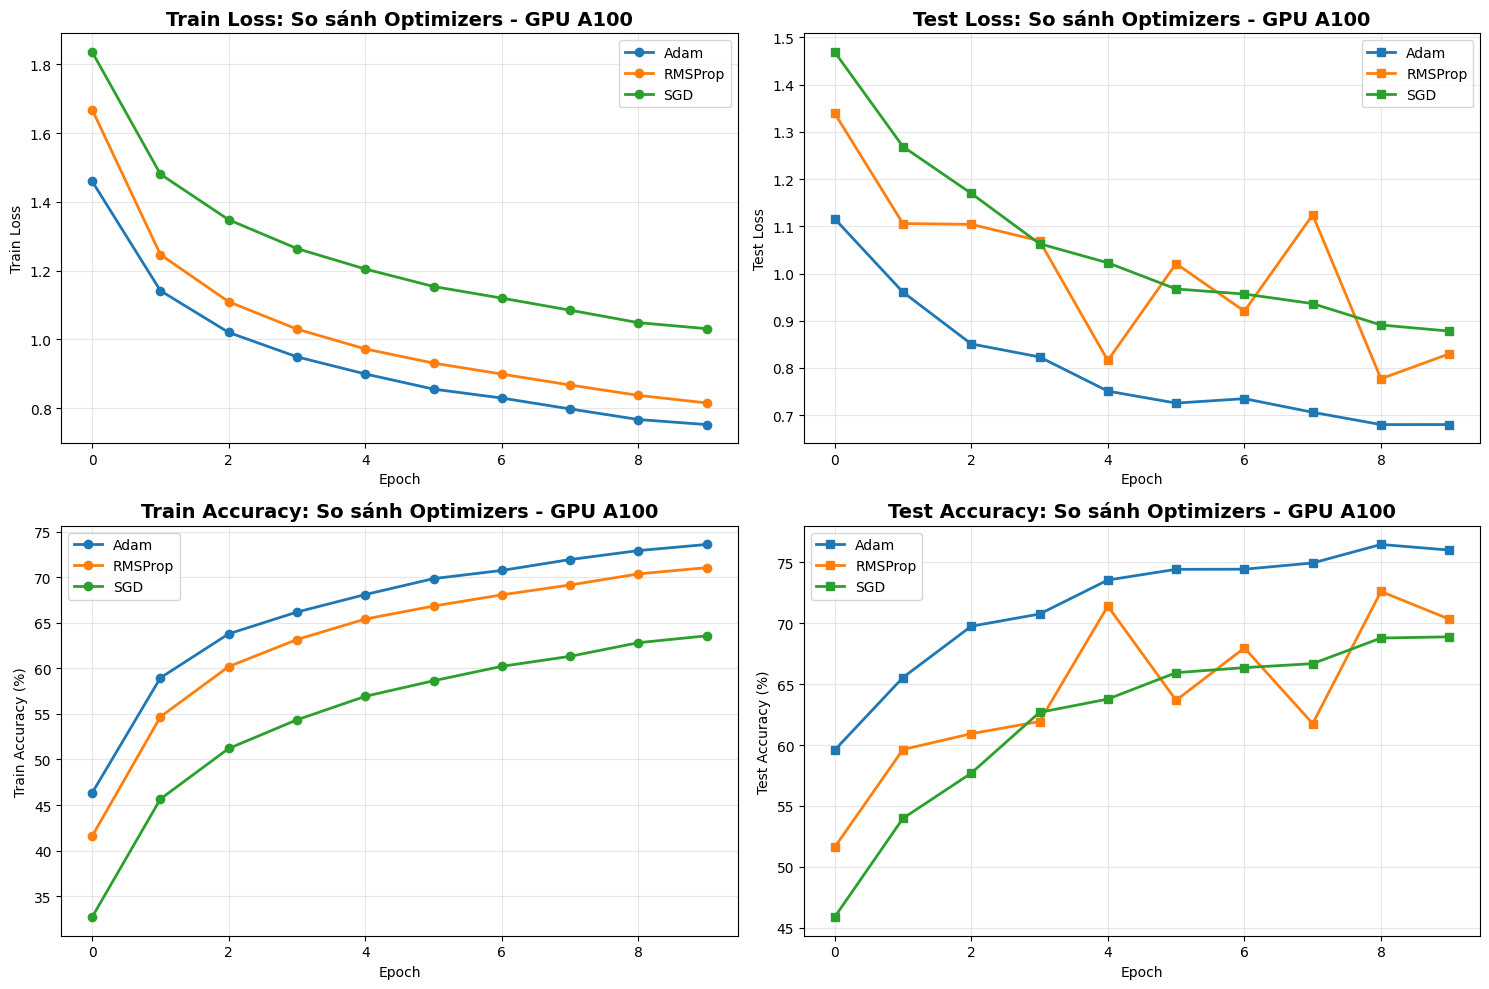


SO SÁNH CÁC OPTIMIZER
Optimizer       Final Train Loss   Final Test Loss    Final Test Acc    
--------------------------------------------------------------------------------
Adam            0.7519             0.6802             76.00             %
RMSProp         0.8149             0.8299             70.33             %
SGD             1.0310             0.8781             68.88             %


In [7]:
def compare_optimizers(histories, labels):
    """So sánh kết quả giữa các optimizer"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss: So sánh Optimizers - GPU A100', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss: So sánh Optimizers - GPU A100', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy: So sánh Optimizers - GPU A100', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy: So sánh Optimizers - GPU A100', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/optimizers_comparison_A100.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*80)
    print("SO SÁNH CÁC OPTIMIZER")
    print("="*80)
    print(f"{'Optimizer':<15} {'Final Train Loss':<18} {'Final Test Loss':<18} {'Final Test Acc':<18}")
    print("-"*80)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<15} {final_train_loss:<18.4f} {final_test_loss:<18.4f} {final_test_acc:<18.2f}%")
    print("="*80)

compare_optimizers([history_adam, history_rmsprop, history_sgd],
                   ['Adam', 'RMSProp', 'SGD'])


## 5. Test độ nhạy: Chạy nhiều lần với cùng optimizer và seed

Để thấy rõ độ nhạy của optimizer với sai số nhỏ, ta sẽ chạy nhiều lần với cùng cấu hình.


TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed

--- Run 1/3 ---

Training với ADAM
  GPU: NVIDIA A100-SXM4-40GB
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.4611, Train Acc: 46.44% | Test Loss: 1.1176, Test Acc: 59.33%
Epoch 2/10: Train Loss: 1.1390, Train Acc: 58.95% | Test Loss: 0.9388, Test Acc: 66.69%
Epoch 3/10: Train Loss: 1.0190, Train Acc: 63.56% | Test Loss: 0.8571, Test Acc: 69.64%
Epoch 4/10: Train Loss: 0.9472, Train Acc: 66.40% | Test Loss: 0.8250, Test Acc: 70.78%
Epoch 5/10: Train Loss: 0.8956, Train Acc: 68.26% | Test Loss: 0.7661, Test Acc: 73.25%
Epoch 6/10: Train Loss: 0.8542, Train Acc: 69.51% | Test Loss: 0.7198, Test Acc: 74.81%
Epoch 7/10: Train Loss: 0.8275, Train Acc: 70.75% | Test Loss: 0.7068, Test Acc: 75.28%
Epoch 8/10: Train Loss: 0.7968, Train Acc: 71.82% | Test Loss: 0.6964, Test Acc: 75.36%
Epoch 9/10: Train Loss: 0.7653, Train Acc: 72.97% | Test Loss: 0.6639, Test Acc: 76.44%
Epoch 10/10: Train Loss: 0.7464, Train Acc: 73.63% | Test Los

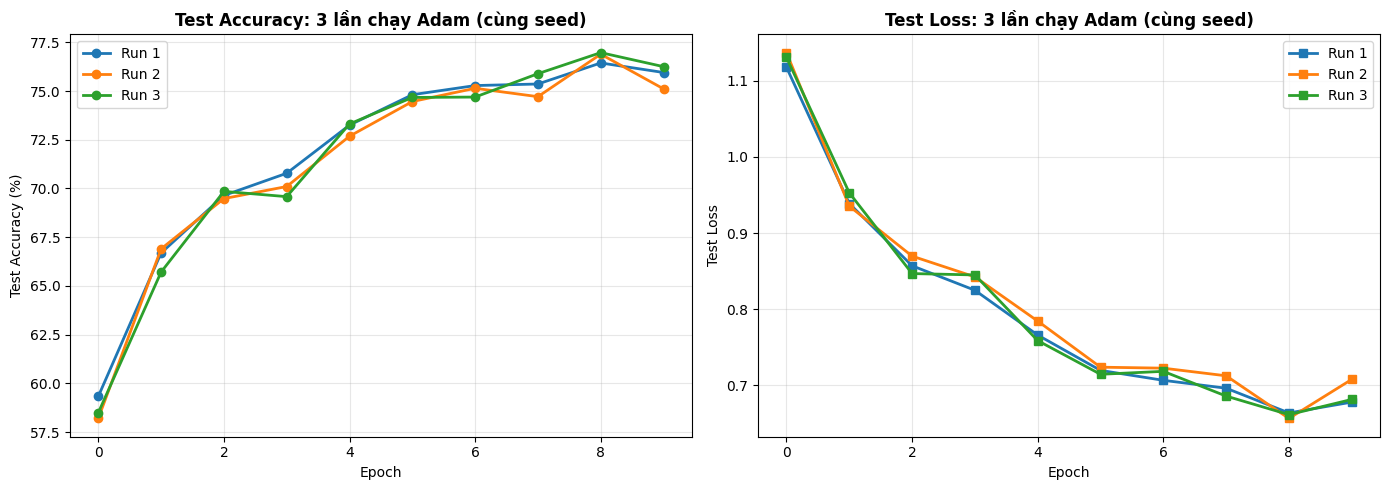

In [8]:
# Chạy Adam 3 lần với cùng seed (nhưng mỗi lần khởi tạo model lại)
print("="*80)
print("TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed")
print("="*80)

adam_runs = []
for run in range(3):
    print(f"\n--- Run {run+1}/3 ---")
    history = train_with_optimizer('Adam', seed=42, num_epochs=10, tf32_enabled=False, save_results=False)
    adam_runs.append(history)

# So sánh các lần chạy
print("\n" + "="*80)
print("SO SÁNH CÁC LẦN CHẠY ADAM (cùng seed)")
print("="*80)
print(f"{'Run':<10} {'Final Test Acc':<18} {'Độ lệch so với Run 1':<20}")
print("-"*80)
baseline_acc = adam_runs[0]['test_acc'][-1]
for i, hist in enumerate(adam_runs):
    acc = hist['test_acc'][-1]
    diff = acc - baseline_acc
    print(f"Run {i+1:<9} {acc:<18.2f}% {diff:+.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, hist in enumerate(adam_runs):
    ax.plot(hist['test_acc'], label=f'Run {i+1}', marker='o', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy: 3 lần chạy Adam (cùng seed)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for i, hist in enumerate(adam_runs):
    ax.plot(hist['test_loss'], label=f'Run {i+1}', marker='s', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss: 3 lần chạy Adam (cùng seed)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/adam_sensitivity_test_A100.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Kết luận cho GPU A100**Đặc điểm GPU A100**:- Compute Capability: 8.0- ✅ Hỗ trợ TF32 (Ampere+)- ✅ Hỗ trợ FP32 và FP16 (với AMP)**Quan sát từ các test trên A100**:1. **Adam và RMSProp** là các adaptive optimizer, sử dụng momentum và learning rate adaptation2. Các optimizer này **khuếch đại sai số nhỏ** từ floating-point precision3. Ngay cả với cùng seed, mỗi lần khởi tạo model lại có thể cho kết quả hơi khác nhau4. Sự khác biệt tích lũy qua các epoch do:   - Adaptive learning rate thay đổi dựa trên gradient history   - Momentum tích lũy sai số nhỏ   - BatchNorm và Dropout cũng góp phần vào non-determinism**Tác động lên Cross-GPU Reproducibility**:- Trên GPU khác nhau, sai số floating-point khác nhau- Optimizer khuếch đại sự khác biệt này- Dẫn đến kết quả cuối cùng có thể khác nhau đáng kể**Khuyến nghị cho A100**:- Hiểu rằng adaptive optimizers (Adam, RMSProp) nhạy cảm hơn với sai số- Khi so sánh kết quả, tập trung vào **xu hướng** chứ không phải giá trị tuyệt đối- Nếu cần reproducibility cao, cân nhắc dùng SGD với momentum cố định**Kết quả**:- Kết quả đã được lưu vào thư mục `results/` với tên GPU A100- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`**Bước tiếp theo**:1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060, H100)2. Copy tất cả file JSON vào cùng thư mục `results/`3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh